### Signal integrity: L-shaped antenna — standard vs. chamfered

This notebook rebuilds the L-shaped antenna (mesh + Physical Groups + a Palace
*Driven* run to extract the **S-parameters**) and compares it with a variant that
adds a **chamfer (miter)** at the inner corner of the microstrip bend.

It is organised in three parts:

1. **Standard L antenna** (no chamfer) — one Palace *Driven* run.
2. **Chamfered L antenna** — same geometry but with a mitered bend.
3. **Signal integrity comparison** — overlaid S-parameters, an **eye diagram** and a
   **bit error rate (BER)** estimate derived from $S_{21}$.

The **time-domain** (transient) simulation lives in the separate
`l_antenna_time_domain.ipynb` notebook.


In [1]:
import math
import gmsh

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from palacetoolkit.simulation import generate_palace_config_from_entities, run_palace
from palacetoolkit.viz import view_mesh
from palacetoolkit.mesh import (
    Entity,
    run_entity_pipeline,
    generate_3d_mesh,
    create_graded_mesh,
)



### Parameters:
- h : Patch height along z-axis, specified as a scalar in meters. 
- l1 : Ground plane length along x-axis, specified as a scalar in meters
- w1 : Ground plane width along y-axis, specified as a scalar in meters
- w3 : Strip line width along y-axis, specified as a scalar in meters.
- air_height : Air box height along z-axis, specified as a scalar in meters.  
- air_margin : Air box margin along x and y axes, specified as a scalar in meters.
- freq  : Simulation frequency in GHz, specified as a scalar.
- filename : Output mesh filename, specified as a string.

In [2]:
l1: float = 0.06
w1: float = 0.06
w3: float = 0.002
h: float = 0.0013
air_height: float = 0.025
air_margin: float = 0.025
freq: float = 3.3
mesh_file: str = "l_antenna.msh"


eps_r: float = 2.2
loss_tan: float = 0.0009

wavelength = 3e8 / (freq * 1e9)
mesh_size = wavelength / 15


### Initialize the model


In [3]:
gmsh.initialize()
gmsh.model.add("patch_antenna")
kernel = gmsh.model.occ


### Geometry Construction


In [4]:
total_xmin = -l1/2 - air_margin
total_xmax = l1/2 + air_margin
total_ymin = -w1/2 - air_margin
total_ymax = w1/2 + air_margin
total_zmax = h + air_height


# 1. Create volumes
substrate = kernel.addBox(-l1/2, -w1/2, 0, l1, w1, h)
airsphere_radius = max(abs(total_xmin), abs(total_xmax), abs(total_ymin), abs(total_ymax), total_zmax)
air_sphere = kernel.addSphere(0.0, 0.0, 0.0, airsphere_radius)
kernel.synchronize()

# 2. Create 2D surfaces (ground, patch, ports)
ground_plane = kernel.addRectangle(-l1/2, -w1/2, 0, l1, w1)

strip_length_x = l1/2
strip_length_y = w1/2 + w3/2

feed_line_x = kernel.addRectangle(-l1/2, -w3/2, h, strip_length_x, w3)
feed_line_y = kernel.addRectangle(0, -w3/2, h, w3, strip_length_y)

top_conductor, top_map = kernel.fuse(
    [(2, feed_line_x)], [(2, feed_line_y)],
    removeObject=True, removeTool=True
)
kernel.synchronize()

# Lumped ports - build directly in-plane, no rotation
# Port 1: at x = -l1/2, vertical face
p1 = kernel.addPoint(-l1/2, -w3/2, 0)
p2 = kernel.addPoint(-l1/2,  w3/2, 0)
p3 = kernel.addPoint(-l1/2,  w3/2, h)
p4 = kernel.addPoint(-l1/2, -w3/2, h)

lp1_a = kernel.addLine(p1, p2)
lp1_b = kernel.addLine(p2, p3)
lp1_c = kernel.addLine(p3, p4)
lp1_d = kernel.addLine(p4, p1)
loop1 = kernel.addCurveLoop([lp1_a, lp1_b, lp1_c, lp1_d])
lumped_port_1 = kernel.addPlaneSurface([loop1])
kernel.synchronize()

# Port 2: at y = w1/2, vertical face
p5 = kernel.addPoint(0,  w1/2, 0)
p6 = kernel.addPoint(w3, w1/2, 0)
p7 = kernel.addPoint(w3, w1/2, h)
p8 = kernel.addPoint(0,  w1/2, h)

lp2_a = kernel.addLine(p5, p6)
lp2_b = kernel.addLine(p6, p7)
lp2_c = kernel.addLine(p7, p8)
lp2_d = kernel.addLine(p8, p5)
loop2 = kernel.addCurveLoop([lp2_a, lp2_b, lp2_c, lp2_d])
lumped_port_2 = kernel.addPlaneSurface([loop2])
kernel.synchronize()

# Define the entities which will be the physical groups.
entities = [
    Entity("substrate", dim=3, btype="dielectric", mesh_order=1, tags=[substrate], loss_tan=loss_tan, eps_r=eps_r, mu_r=1.0),
    Entity("air_sphere", dim=3, btype="dielectric", mesh_order=2, tags=[air_sphere], loss_tan=0.0, eps_r=1.0, mu_r=1.0),
    Entity("top_conductor", dim=2, btype="pec", mesh_order=1, tags=[top_conductor[0][1]]),
    Entity("ground_plane", dim=2, btype="pec", mesh_order=1, tags=[ground_plane]),
    Entity("lumped_port_1", dim=2, btype="lumped_port", mesh_order=0, tags=[lumped_port_1], R=50.0, direction="+Z", excitation=True),
    Entity("lumped_port_2", dim=2, btype="lumped_port", mesh_order=0, tags=[lumped_port_2], R=50.0, direction="+Z", excitation=False),
]


Info    : Cannot bind existing OpenCASCADE surface 9 to second tag 10                                                                       
Info    : Could not preserve tag of 2D object 10 (->9)


In [5]:
pg_map = run_entity_pipeline(entities)

lumped_port_1 = entities[-1].dimtags[0]
lumped_port_2 =  entities[-2].dimtags[0]

# Refine near the top conductor and also locally refine the ports.
create_graded_mesh(  wavelength, 
                     ppw_near=100, 
                     ppw_far=15, 
                     set_as_background=True,
                     local_refinements = {lumped_port_1: 100, lumped_port_2 : 100})

mesh_sizes = {
    "substrate": wavelength / 12,
    "air_sphere": wavelength / 4,
    "lumped_port_1": wavelength / 18,
    "lumped_port_2": wavelength / 18,
    "top_conductor": wavelength /10
}

generate_3d_mesh(entities, mesh_sizes, mesh_file, optimize=True, verbose=False)
gmsh.finalize()

  Physical group 'substrate' (dim=3): pg=1, tags=[1]                                                                                             
  Physical group 'air_sphere' (dim=3): pg=2, tags=[2]
  Physical group 'top_conductor' (dim=2): pg=3, tags=[9]
  Physical group 'ground_plane' (dim=2): pg=4, tags=[8]
  Physical group 'lumped_port_1' (dim=2): pg=5, tags=[10]
  Physical group 'lumped_port_2' (dim=2): pg=6, tags=[11]
  Physical group 'air_sphere__substrate' (dim=2): pg=7, tags=[12, 13, 14, 15, 16, 17, 18, 19]
  Physical group 'air_sphere__None' (dim=2): pg=8, tags=[20]
  ignoring 3 curves from {'air_sphere__None'}
  global: 28 curves, SizeMin=0.0009
  ppw_near=100  ppw_far=15
  SizeMax=0.0061  transition=0.0227
  local: dimtag=(2, 11), ppw=100, SizeMin=0.0009
  local: dimtag=(2, 10), ppw=100, SizeMin=0.0009


Loading mesh file: l_antenna.msh
Groups to render transparent: air_sphere__None

Mesh loaded successfully with 2 cell blocks
Found 10310 triangles total
Physical group tags in mesh: {3: 'top_conductor', 4: 'ground_plane', 5: 'lumped_port_1', 6: 'lumped_port_2', 7: 'air_sphere__substrate', 8: 'air_sphere__None'}



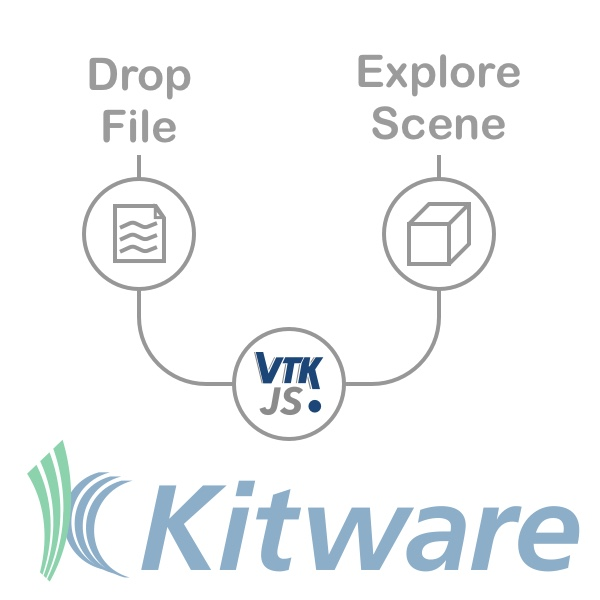

In [6]:
view_mesh(mesh_file, transparent_groups= "air_sphere__None")

### Simulation Configuration

We define the key parameters for the **driven** electromagnetic simulation: the
frequency sweep range, material properties (dielectric constant and loss tangent of
the substrate), and solver-specific settings such as port impedance and element
order.

- output_file  : output filename for the configuration JSON file
- freq_min/freq_max/freq_step : driven frequency sweep (GHz)
- eps_r: relative permittivity of the substrate
- loss_tan: loss tangent of the substrate
- port_impedance: characteristic impedance of the lumped ports (Ohms)
- solver_order: order of the finite element basis functions


In [7]:
output_file_driven: str = "l_antenna_driven.json"

eps_r: float = 2.2
loss_tan: float = 0.0009
port_impedance: float = 50.0
solver_order: int = 2

freq_min = 1.0
freq_max = 15.0
freq_step = 0.5


### Generating the Palace Configuration File

We assemble the simulation parameters into the JSON configuration for the **driven**
sweep used to obtain the S-parameters.


In [8]:
config_driven = generate_palace_config_from_entities(
    entity_defs=[e.to_dict() for e in entities],
    pg_map=pg_map,
    mesh_file=mesh_file,
    output_file=output_file_driven,
    sim_type="driven",
    L0=1.0,
    solver_order=solver_order,
    absorbing_order=1,
    farfield=False,
    freq_min=freq_min,
    freq_max=freq_max,
    freq_step=freq_step,
    linear_maxits=300,
)


Palace config written to l_antenna_driven.json


### Running PALACE


In [ ]:
run_palace(config_file="l_antenna_driven.json", num_procs=1)


### S-parameters

After the driven run the S-parameter magnitude/phase are written to
`postpro/l_antenna_driven/port-S.csv`. We load them as complex quantities so they can
be reused both for the comparison plot and for the signal-integrity (BER) analysis.


In [9]:
def load_s2p(csv_path):
    """Read Palace port-S.csv (5 columns) and return (f_GHz, S11, S21) complex."""
    data = np.loadtxt(csv_path, delimiter=",", skiprows=1)
    f = data[:, 0]

    def comp(mag_col, pha_col):
        mag = 10 ** (data[:, mag_col] / 20.0)
        return mag * np.exp(1j * np.deg2rad(data[:, pha_col]))

    return f, comp(1, 2), comp(3, 4)


notebook_dir = Path().resolve()
base = notebook_dir / "postpro"

f_std, s11_std, s21_std = load_s2p(str(base / "l_antenna_driven" / "port-S.csv"))
f_ch, s11_ch, s21_ch = load_s2p(str(base / "l_antenna_chamfered_driven" / "port-S.csv"))


### Chamfered L-Antenna

Now repeat the analysis with a 45° chamfer (miter) at the inner corner of the bend.
Chamfering a right-angle microstrip bend reduces the discontinuity capacitance,
improving return loss and signal integrity at high frequencies.


In [10]:
chamfer: float = 0.6 * w3
mesh_file_ch: str = "l_antenna_chamfered.msh"

total_xmin = -l1/2 - air_margin
total_xmax = l1/2 + air_margin
total_ymin = -w1/2 - air_margin
total_ymax = w1/2 + air_margin
total_zmax = h + air_height

gmsh.initialize()
gmsh.model.add("patch_antenna_chamfered")
kernel = gmsh.model.occ

c = chamfer
poly_pts = [
    (-l1/2, -w3/2, h),
    (w3 - c, -w3/2, h),
    (w3, -w3/2 + c, h),
    (w3, w1/2, h),
    (0, w1/2, h),
    (0, w3/2, h),
    (-l1/2, w3/2, h),
]
pt_tags = [kernel.addPoint(x, y, z) for x, y, z in poly_pts]
lines = []
for i in range(len(pt_tags)):
    lines.append(kernel.addLine(pt_tags[i], pt_tags[(i+1) % len(pt_tags)]))
loop = kernel.addCurveLoop(lines)
top_conductor_ch = kernel.addPlaneSurface([loop])
kernel.synchronize()

substrate = kernel.addBox(-l1/2, -w1/2, 0, l1, w1, h)
airsphere_radius = max(abs(total_xmin), abs(total_xmax),
                        abs(total_ymin), abs(total_ymax), total_zmax)
air_sphere = kernel.addSphere(0.0, 0.0, 0.0, airsphere_radius)
ground_plane = kernel.addRectangle(-l1/2, -w1/2, 0, l1, w1)

# Port 1 at x = -l1/2
pa = kernel.addPoint(-l1/2, -w3/2, 0)
pb = kernel.addPoint(-l1/2,  w3/2, 0)
pc = kernel.addPoint(-l1/2,  w3/2, h)
pd = kernel.addPoint(-l1/2, -w3/2, h)
la = kernel.addLine(pa, pb)
lb = kernel.addLine(pb, pc)
lc = kernel.addLine(pc, pd)
ld = kernel.addLine(pd, pa)
loop1 = kernel.addCurveLoop([la, lb, lc, ld])
lumped_port_1 = kernel.addPlaneSurface([loop1])

# Port 2 at y = w1/2
pe = kernel.addPoint(0,  w1/2, 0)
pf = kernel.addPoint(w3, w1/2, 0)
pg = kernel.addPoint(w3, w1/2, h)
ph = kernel.addPoint(0,  w1/2, h)
le = kernel.addLine(pe, pf)
lf = kernel.addLine(pf, pg)
lg = kernel.addLine(pg, ph)
lh = kernel.addLine(ph, pe)
loop2 = kernel.addCurveLoop([le, lf, lg, lh])
lumped_port_2 = kernel.addPlaneSurface([loop2])
kernel.synchronize()

entities_ch = [
    Entity("substrate", dim=3, btype="dielectric", mesh_order=1,
           tags=[substrate], loss_tan=loss_tan, eps_r=eps_r, mu_r=1.0),
    Entity("air_sphere", dim=3, btype="dielectric", mesh_order=2,
           tags=[air_sphere], loss_tan=0.0, eps_r=1.0, mu_r=1.0),
    Entity("top_conductor", dim=2, btype="pec", mesh_order=1,
           tags=[top_conductor_ch]),
    Entity("ground_plane", dim=2, btype="pec", mesh_order=1, tags=[ground_plane]),
    Entity("lumped_port_1", dim=2, btype="lumped_port", mesh_order=0,
           tags=[lumped_port_1], R=50.0, direction="+Z", excitation=True),
    Entity("lumped_port_2", dim=2, btype="lumped_port", mesh_order=0,
           tags=[lumped_port_2], R=50.0, direction="+Z", excitation=False),
]
# The pipeline does the boolean fragment, assigns physical groups and builds
# the substrate/air interface surfaces for us.
pg_map_ch = run_entity_pipeline(entities_ch)

lumped_port_1 = entities_ch[-1].dimtags[0]
lumped_port_2 = entities_ch[-2].dimtags[0]

create_graded_mesh(wavelength,
                    ppw_near=30,
                    ppw_far=15,
                    set_as_background=True,
                    local_refinements={
                        lumped_port_1: 30,
                        lumped_port_2: 30
                    })

mesh_sizes_ch = {
    "substrate": wavelength / 12,
    "air_sphere": wavelength / 4,
    "lumped_port_1": wavelength / 18,
    "lumped_port_2": wavelength / 18,
    "top_conductor": wavelength / 10
}

generate_3d_mesh(entities_ch, mesh_sizes_ch, mesh_file_ch,
                 optimize=True, verbose=False)
gmsh.finalize()


  Physical group 'substrate' (dim=3): pg=1, tags=[1]apes                                                                                         
  Physical group 'air_sphere' (dim=3): pg=2, tags=[2]
  Physical group 'top_conductor' (dim=2): pg=3, tags=[1]
  Physical group 'ground_plane' (dim=2): pg=4, tags=[9]
  Physical group 'lumped_port_1' (dim=2): pg=5, tags=[10]
  Physical group 'lumped_port_2' (dim=2): pg=6, tags=[11]
  Physical group 'air_sphere__substrate' (dim=2): pg=7, tags=[12, 13, 14, 15, 16, 17, 18, 19]
  Physical group 'air_sphere__None' (dim=2): pg=8, tags=[20]
  ignoring 3 curves from {'air_sphere__None'}
  global: 29 curves, SizeMin=0.0030
  ppw_near=30  ppw_far=15
  SizeMax=0.0061  transition=0.0227
  local: dimtag=(2, 11), ppw=30, SizeMin=0.0030
  local: dimtag=(2, 10), ppw=30, SizeMin=0.0030


Loading mesh file: l_antenna_chamfered.msh
Groups to render transparent: air_sphere__None

Mesh loaded successfully with 2 cell blocks
Found 4412 triangles total
Physical group tags in mesh: {3: 'top_conductor', 4: 'ground_plane', 5: 'lumped_port_1', 6: 'lumped_port_2', 7: 'air_sphere__substrate', 8: 'air_sphere__None'}



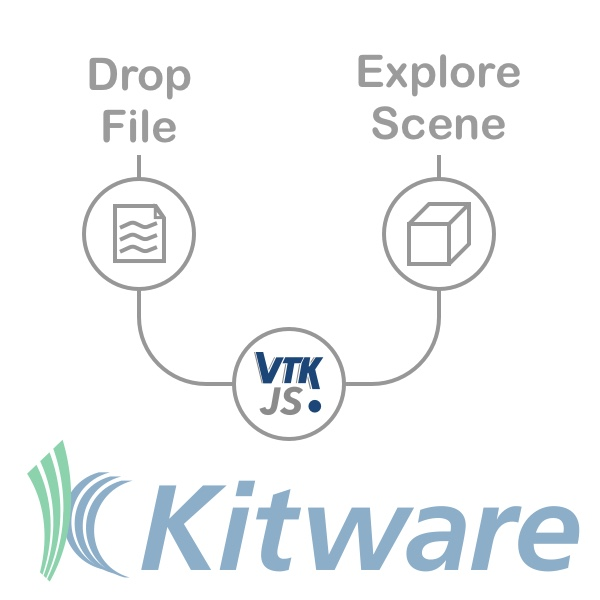

In [11]:
view_mesh(mesh_file_ch, transparent_groups= "air_sphere__None")

In [12]:
output_file_driven_ch = "l_antenna_chamfered_driven.json"

config_driven_ch = generate_palace_config_from_entities(
    entity_defs=[e.to_dict() for e in entities_ch],
    pg_map=pg_map_ch,
    mesh_file=mesh_file_ch,
    output_file=output_file_driven_ch,
    sim_type="driven",
    L0=1.0,
    solver_order=solver_order,
    absorbing_order=1,
    farfield=False,
    freq_min=freq_min,
    freq_max=freq_max,
    freq_step=freq_step,
    linear_maxits=300,
)


Palace config written to l_antenna_chamfered_driven.json


In [ ]:
run_palace(config_file=output_file_driven_ch, num_procs=1)


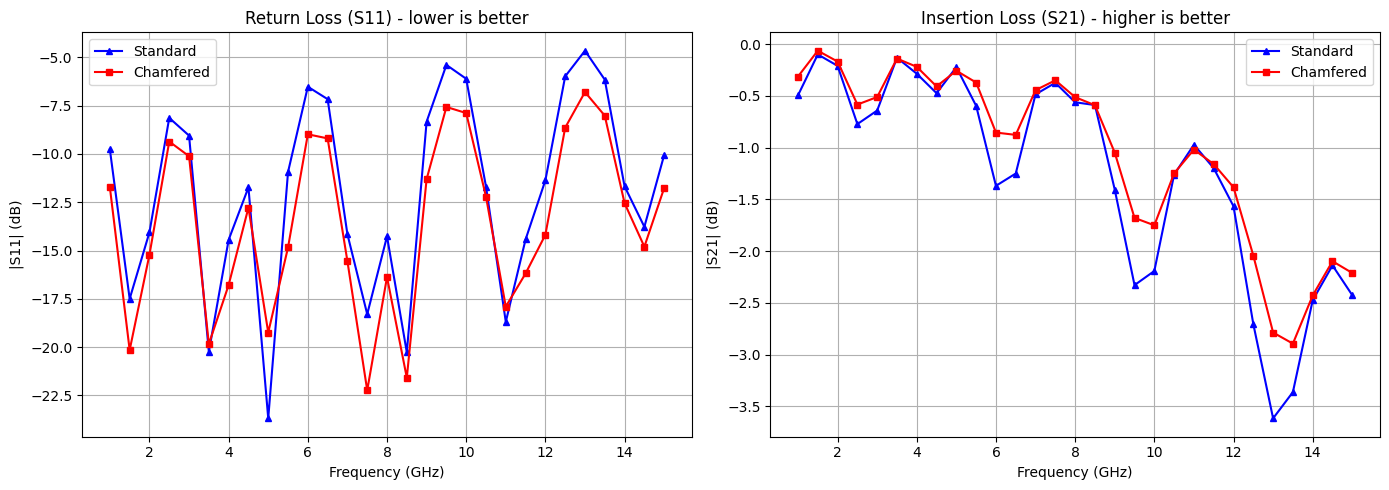

Standard  - min |S11| = -23.7 dB @ 5.000 GHz
Chamfered - min |S11| = -22.2 dB @ 7.500 GHz
|S21| at S11 min: standard = -0.22 dB, chamfered = -0.35 dB


In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(f_std, 20*np.log10(np.abs(s11_std)), "b-^", label="Standard", markersize=4)
ax1.plot(f_ch, 20*np.log10(np.abs(s11_ch)), "r-s", label="Chamfered", markersize=4)
ax1.set_xlabel("Frequency (GHz)")
ax1.set_ylabel("|S11| (dB)")
ax1.set_title("Return Loss (S11) - lower is better")
ax1.legend()
ax1.grid(True)

ax2.plot(f_std, 20*np.log10(np.abs(s21_std)), "b-^", label="Standard", markersize=4)
ax2.plot(f_ch, 20*np.log10(np.abs(s21_ch)), "r-s", label="Chamfered", markersize=4)
ax2.set_xlabel("Frequency (GHz)")
ax2.set_ylabel("|S21| (dB)")
ax2.set_title("Insertion Loss (S21) - higher is better")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

idx_std = np.argmin(20*np.log10(np.abs(s11_std)))
idx_ch = np.argmin(20*np.log10(np.abs(s11_ch)))
print(f"Standard  - min |S11| = {20*np.log10(np.abs(s11_std))[idx_std]:.1f} dB @ {f_std[idx_std]:.3f} GHz")
print(f"Chamfered - min |S11| = {20*np.log10(np.abs(s11_ch))[idx_ch]:.1f} dB @ {f_ch[idx_ch]:.3f} GHz")
print(f"|S21| at S11 min: standard = {20*np.log10(np.abs(s21_std))[idx_std]:.2f} dB, chamfered = {20*np.log10(np.abs(s21_ch))[idx_ch]:.2f} dB")


### Signal integrity: bit error rate (BER)

We treat the structure as a 2-port link whose passband frequency response is the
measured $S_{21}(f)$, and estimate the **bit error rate (BER)** of an OOK (on-off
keying) NRZ sequence transmitted through it:

1. Build the **channel impulse response** (inverse FFT of $S_{21}$, band-limited with
   a raised-cosine edge taper).
2. Transmit an **OOK** sequence modulated on a 5 GHz carrier (400 Mb/s) and convolve
   it with the channel response.
3. Add **AWGN** with a fixed signal-to-noise ratio and recover the **envelope** at
   the receiver.
4. Sample at the centre of each symbol and count errors; the **BER** is also
   estimated from the **Q factor** (BER = ½ erfc(Q/√2)).

Everything uses NumPy and `math.erfc` — no SciPy.


In [ ]:
# ── Channel model from S21 (magnitude + phase) ──────────────────────────
def s21_passband_spectrum(s21, f_ghz, f_bins_ghz, fc_ghz, bw_ghz):
    """Interpolate complex S21 on the FFT grid within [fc-bw/2, fc+bw/2]."""
    f1, f2 = fc_ghz - bw_ghz / 2, fc_ghz + bw_ghz / 2
    roll = 0.1 * bw_ghz
    H = np.zeros(len(f_bins_ghz), dtype=complex)
    for i, fk in enumerate(f_bins_ghz):
        if f1 <= fk <= f2:
            re = np.interp(fk, f_ghz, s21.real)
            im = np.interp(fk, f_ghz, s21.imag)
            if fk < f1 + roll:
                w = 0.5 * (1 - math.cos(math.pi * (fk - f1) / roll))
            elif fk > f2 - roll:
                w = 0.5 * (1 - math.cos(math.pi * (f2 - fk) / roll))
            else:
                w = 1.0
            H[i] = (re + 1j * im) * w
    return H


def simulate_ook(s21, f_ghz, bits, Ns, dt, fc_ghz, bw_ghz, snr_db=12.0, seed=12345):
    """NRZ OOK passband link: Tx → channel (S21) → AWGN → received envelope."""
    rng = np.random.default_rng(seed)
    fc = fc_ghz * 1e9
    N = bits.size * Ns
    t = np.arange(N) * dt
    tx = np.repeat(bits, Ns) * np.cos(2 * np.pi * fc * t)

    f_pos = np.fft.rfftfreq(N, dt) * 1e-9          # GHz
    H = s21_passband_spectrum(s21, f_ghz, f_pos, fc_ghz, bw_ghz)
    h = np.fft.irfft(H, n=N)
    lag = int(np.argmax(np.abs(h)))
    y = np.roll(np.fft.irfft(np.fft.rfft(tx) * np.fft.rfft(h), n=N), -lag)

    noise = rng.standard_normal(N)
    noise *= np.sqrt(np.mean(y**2)) * 10 ** (-snr_db / 20.0)
    r = y + noise

    spec = np.fft.fft(r)                           # envelope = |analytic|
    spec[N // 2 + 1:] = 0
    return np.abs(np.fft.ifft(spec))


def estimate_ber(env, bits, Ns, guard=8):
    """Sample the envelope at each symbol centre and count bit errors."""
    n_sym = len(env) // Ns
    k = np.arange(guard, n_sym)
    samples = env[k * Ns + Ns // 2]
    b = bits[guard:n_sym]

    lvl1 = samples[b == 1]
    lvl0 = samples[b == 0]
    th = 0.5 * (lvl1.mean() + lvl0.mean())
    rx = np.where(samples > th, 1, 0)
    ber_count = float(np.mean(rx != b))

    q = (lvl1.mean() - lvl0.mean()) / (1e-30 + lvl1.std() + lvl0.std())
    ber_q = 0.5 * math.erfc(q / math.sqrt(2))
    return ber_count, ber_q, q


In [ ]:
# Link parameters (shared by both variants)
fc_si = 5.0                 # channel centre frequency [GHz]
bw_si = 4.0                 # analysis bandwidth [GHz]
Rb = 0.4e9                  # 400 Mb/s
Ns = 32
dt_si = (1 / Rb) / Ns
L_bits = 256
bits = np.random.default_rng(7).integers(0, 2, L_bits)   # bits {0,1} (OOK)

print()
header = f"{'Variant':<10}{'|S21|@fc(dB)':<16}{'BER count':<13}{'BER (Q)':<12}{'Q':<8}"
print(header)
print('-' * len(header))
for label, s21, f in [("standard", s21_std, f_std), ("chamfered", s21_ch, f_ch)]:
    env = simulate_ook(s21, f, bits, Ns, dt_si, fc_si, bw_si, snr_db=12.0)
    ber_count, ber_q, q = estimate_ber(env, bits, Ns, guard=8)
    s21_db = 20 * np.log10(np.interp(fc_si, f, np.abs(s21)))
    print(f"{label:<10}{s21_db:<16.2f}{ber_count:<13.2e}{ber_q:<12.2e}{q:<8.2f}")


### Conclusions

Comparing the two variants, the **BER** at a fixed SNR shows the impact of the
chamfer on signal integrity:
- If the chamfered antenna yields a **lower BER** for the same SNR, the chamfer
  improves the quality of the link through the bend.
- The difference depends on the size of `chamfer`; sweep the parameter by repeating
  Part 2 with other values.
